# Vectorización de Texto: Métodos Frecuentistas
## UNR · TUIA · Procesamiento de Lenguaje Natural — Unidad 2

Para que un modelo pueda trabajar con texto, primero hay que convertirlo en números.
En esta práctica exploramos los métodos clásicos con un dataset real de libros.

| Parte | Tema | Ejercicios |
|-------|------|-----------|
| 1 | Preparación del dataset | Ej 1, 2 |
| 2 | One-Hot Encoding | Ej 3 |
| 3 | Count Vectorizer | Ej 4 |
| 4 | N-grams | — (solo lectura) |
| 5 | TF-IDF | Ej 5 |
| 6 | Hash Vectorizer | — (solo lectura) |
| 7 | Comparación de métodos | Ej 6, 7 |
| 8 | Visualización con PCA | Ej 8 |

> **Texto**: sinopsis (`sinapsis`) · **Etiqueta**: subgénero · **Dataset**: Lectulandia


---
## 📌 Notas de esta resolución

- **Cómo se ejecutó:** localmente, con el kernel `Python 3.12 (NLP TUIA)` y `U2/practicas/` como carpeta de trabajo, porque el notebook lee `data/...`. La línea `!pip install` de la primera celda quedó comentada: es de Colab.
- Cada función `TODO` conserva su firma y su consigna; solo se completó el cuerpo. Después de cada ejercicio hay una celda **📝 Interpretación** que explica qué muestra el resultado y por qué.
- Las celdas marcadas como **Extra** no las pide la consigna. Sirven para verificar algo o para entender mejor un resultado.

### ⚠️ Errores de consigna detectados

1. **El dataset no es el que describe la Parte 1.** El texto habla de ~476 libros y de un top 3 de Crónica (~169), Ensayo (~78) y Divulgación (~59). Esos números corresponden a los 464 libros con el género *Biografía*. El CSV que se descarga es el catálogo completo (62.279 libros). Con él, el top 3 del 2.º género es **Novela (16.634), Relato (2.892) y Otros (2.704)**.
2. **El "2.º género" no es "el más discriminativo".** Los géneros de cada libro vienen en **orden alfabético**: se verifica en el Ejercicio 1, y pasa en el 100 % de los libros. La posición en la lista no dice nada del libro. "Novela" queda 2.ª cuando el otro género empieza con una letra anterior a la N (Intriga, Histórico, Drama…). Y "Otros" es, en el 76 % de los casos, una novela sin subgénero ("Novela - Otros").
3. **El Ejercicio 7 usa como "mejor modelo" TF-IDF con bigramas**, pero en el Ejercicio 6 empata con TF-IDF base y con TF-IDF sublineal: las diferencias son de 0,003, menores que el desvío entre folds. Se respetó la consigna.
4. **La Parte 8 se titula "PCA", pero usa `TruncatedSVD`.** Sobre TF-IDF, eso es **LSA**: SVD sin centrar los datos. No es exactamente PCA (ver la nota de la Parte 8).
5. **"Los primeros 2 componentes suelen capturar el 10–15 % de la varianza":** acá capturan el **2,0 %** (TF-IDF base) y el **0,7 %** (bigramas). Para llegar al 12,6 % hacen falta 50 componentes.
6. Detalle menor: la tabla de la Parte 7 y el docstring del Ejercicio 6 difieren en algunos parámetros (`min_df=2` en TF-IDF sublin, `max_features=8000` en bigramas). Se siguió el docstring.


In [1]:
# ── Dependencias ─────────────────────────────────────────────────────────────
# !pip install scikit-learn numpy pandas matplotlib seaborn   # solo en Colab

import re, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse

from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, HashingVectorizer
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
np.random.seed(42)

print("Imports OK")


Imports OK


In [2]:
# ── Descarga del dataset ──────────────────────────────────────────────────────
import os, urllib.request

DATA_PATH = "data/lectulandia_books.csv"
GDRIVE_ID = "147g4SlXZtguJ7LZ1-9zxaHiYXlTApqru"

os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)

if not os.path.exists(DATA_PATH):
    print("Descargando lectulandia_books.csv desde Google Drive...")
    try:
        import gdown
        gdown.download(id=GDRIVE_ID, output=DATA_PATH, quiet=False)
    except ImportError:
        # Fallback sin gdown (funciona para archivos públicos sin confirmación)
        url = f"https://drive.google.com/uc?export=download&id={GDRIVE_ID}"
        urllib.request.urlretrieve(url, DATA_PATH)
    print(f"Dataset guardado en: {DATA_PATH}")
else:
    print(f"Dataset ya existe en: {DATA_PATH}")


Dataset ya existe en: data/lectulandia_books.csv


---
# Parte 1 – Preparación del Dataset

## El dataset: Lectulandia

Tenemos un CSV con ~476 libros. Cada fila tiene:

| Columna | Ejemplo |
|---------|---------|
| `titulo` | "El año del pensamiento mágico" |
| `autor` | "Joan Didion" |
| `sinapsis` | Texto libre de ~200 palabras |
| `generos` | "Biografía - Crónica - Literatura" |

El campo `generos` puede tener varios valores separados por ` - `. Vamos a usar el
**segundo género** como etiqueta de clase (es el más discriminativo).

## ¿Por qué balancear?

Los tres subgéneros más frecuentes tienen muy distinta cantidad de libros:
Crónica tiene ~169, Ensayo ~78 y Divulgación ~59.

Si dejamos ese desbalance, el modelo aprende a predecir siempre la clase mayoritaria
y parece bueno sin aprender nada útil. Por eso tomamos la misma cantidad de libros
de cada clase.

## Limpieza del texto

Antes de vectorizar, limpiamos cada sinopsis:

```python
import re

def limpiar_texto(texto):
    texto = texto.lower()                       # minúsculas
    texto = re.sub(r"[^\w\s]", " ", texto)    # sin puntuación
    texto = re.sub(r"\d+", " ", texto)         # sin números
    texto = re.sub(r"\s+", " ", texto).strip() # sin espacios dobles
    return texto
```


### Ejercicio 1 – Preparar el Dataset

In [3]:
def limpiar_texto(texto):
    """La limpieza de la consigna: minúsculas, sin puntuación, sin números."""
    texto = texto.lower()
    texto = re.sub(r"[^\w\s]", " ", texto)     # sin puntuación (\w conserva tildes y ñ)
    texto = re.sub(r"\d+", " ", texto)          # sin números
    texto = re.sub(r"\s+", " ", texto).strip()  # sin espacios dobles
    return texto


def preparar_dataset(path):
    """
    TODO:
    1. Cargar el CSV y eliminar filas con sinapsis o géneros vacíos
    2. Extraer el 2° género como etiqueta ('label')
    3. Quedarse con los top-3 géneros y balancear (random_state=42)
    4. Limpiar la sinopsis → columna 'sinapsis_clean'
       (minúsculas, sin puntuación, sin números)
    """
    # 1. Cargar y descartar filas sin texto o sin etiqueta
    df = pd.read_csv(path)
    df = df.dropna(subset=["sinapsis", "generos"])
    df = df[df["sinapsis"].str.strip().ne("") & df["generos"].str.strip().ne("")]
    print(f"Libros con sinopsis y géneros: {len(df):,}")

    # 2. Etiqueta = 2.º género ("Biografía - Crónica - Literatura" → "Crónica").
    #    Los libros con un único género no tienen 2.º y quedan afuera.
    df = df[df["generos"].str.split(" - ").str.len() >= 2].copy()
    df["label"] = df["generos"].str.split(" - ").str[1].str.strip()

    # 3. Top 3 y balanceo: cada clase se submuestrea al tamaño de la más chica
    top3 = df["label"].value_counts().head(3)
    print("\nTop 3 del 2.º género, antes de balancear:")
    print(top3.to_string())
    n_por_clase = top3.min()
    df = (df[df["label"].isin(top3.index)]
          .groupby("label", group_keys=False)
          .sample(n=n_por_clase, random_state=42)
          .sample(frac=1, random_state=42)          # mezclar: si no, quedan ordenados por clase
          .reset_index(drop=True))

    # 4. Limpieza
    df["sinapsis_clean"] = df["sinapsis"].apply(limpiar_texto)
    print(f"\nDataset final: {len(df):,} libros ({n_por_clase:,} por género)")
    return df


df = preparar_dataset(DATA_PATH)

Libros con sinopsis y géneros: 47,830

Top 3 del 2.º género, antes de balancear:
label
Novela    16634
Relato     2892
Otros      2704



Dataset final: 8,112 libros (2,704 por género)


In [4]:
# ── Verificación: ¿qué es el "2.º género"? ───────────────────────────────────
import unicodedata

def quitar_acentos(texto):
    # Como en el apunte de la Unidad 1: NFKD separa "á" en "a" + tilde, y se descarta la tilde
    nfkd = unicodedata.normalize("NFKD", texto)
    return "".join(c for c in nfkd if not unicodedata.combining(c))

def generos_en_orden(generos):
    lista = generos.split(" - ")
    return lista == sorted(lista, key=quitar_acentos)

crudo = pd.read_csv(DATA_PATH).dropna(subset=["generos"])

# 1) ¿Las listas de géneros vienen en orden alfabético?
en_orden = crudo["generos"].apply(generos_en_orden)
print(f"Listas de géneros en orden alfabético: {en_orden.mean():.1%} de {len(crudo):,}")

# 2) El subconjunto para el que parece escrita la consigna: los libros de "Biografía"
bio = crudo[crudo["generos"].str.contains("Biografía")]
print(f"\nLibros con 'Biografía' entre sus géneros: {len(bio)}")
print("Su 2.º género más frecuente:")
print(bio["generos"].str.split(" - ").str[1].value_counts().head(3).to_string())


Listas de géneros en orden alfabético: 100.0% de 62,278

Libros con 'Biografía' entre sus géneros: 464
Su 2.º género más frecuente:
generos
Crónica        171
Ensayo          74
Divulgación     60


#### 📝 Interpretación — Ejercicio 1

- Quedan **8.112 libros, 2.704 por género** (Novela, Relato y Otros). El balanceo recorta todo al tamaño de la clase más chica: de Novela se descartan unos 14 mil libros. Así, predecir siempre la misma clase da un 33 % de aciertos (el azar), y la accuracy no queda inflada por la clase mayoritaria.
- **Ojo con la etiqueta** (ver la verificación de arriba). Como los géneros vienen en orden alfabético, el "2.º género" es un efecto del orden, y las tres clases no son géneros temáticos:
  - **Novela:** libros como "Intriga - Novela" o "Histórico - Novela". El subgénero real es el 1.º.
  - **Otros:** el 76 % son "Novela - Otros", es decir, novelas *sin* subgénero.
  - **Relato:** colecciones de cuentos ("Fantástico - Relato", "Otros - Relato").

  En la práctica, el clasificador va a distinguir **formatos** (novela con subgénero, novela sin subgénero, cuentos), no temas. Eso explica buena parte de los resultados de los ejercicios 5 a 7.


### Ejercicio 2 – Explorar el Corpus

Libros por género:
label
Novela    2704
Relato    2704
Otros     2704


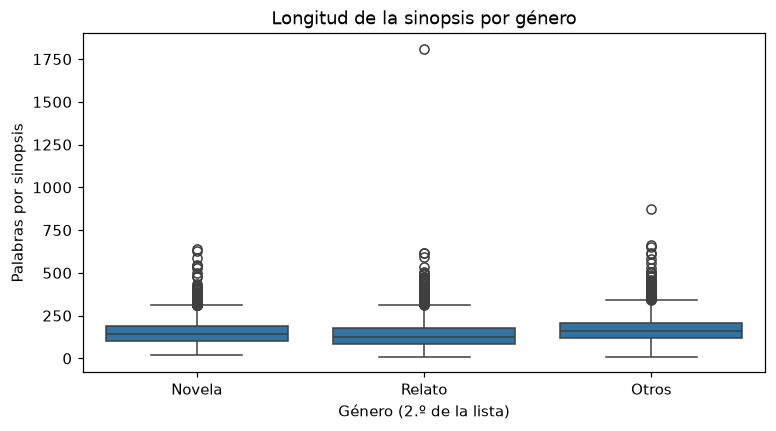

        media  mediana     max
label                         
Novela  150.0    140.0   639.0
Otros   169.0    159.0   872.0
Relato  137.0    124.0  1810.0



Top 10 palabras del corpus (sin stopwords):
  vida          3,886
  novela        2,860
  historia      2,598
  mundo         2,509
  años          2,410
  ser           1,919
  libro         1,824
  relatos       1,766
  dos           1,755
  vez           1,696


In [5]:
# Stopwords del español de NLTK, como en el apunte de la Unidad 1
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
STOPWORDS_ES = set(stopwords.words("spanish"))


def explorar_corpus(df):
    """
    TODO:
    1. Mostrar cuántos libros hay por género
    2. Graficar la longitud de sinopsis por género (boxplot)
    3. Mostrar las 10 palabras más frecuentes del corpus
       (excluir stopwords básicas como 'el', 'de', 'la', etc.)
    """
    # 1. Libros por género
    print("Libros por género:")
    print(df["label"].value_counts().to_string())

    # 2. Longitud de la sinopsis (en palabras) por género
    largo = df["sinapsis_clean"].str.split().str.len()
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(x=df["label"], y=largo, ax=ax)
    ax.set(xlabel="Género (2.º de la lista)", ylabel="Palabras por sinopsis",
           title="Longitud de la sinopsis por género")
    plt.show()
    print(largo.groupby(df["label"]).describe()[["mean", "50%", "max"]]
          .round(0).rename(columns={"mean": "media", "50%": "mediana"}).to_string())

    # 3. Top 10 palabras del corpus sin stopwords (y sin restos de 1-2 letras)
    conteo = Counter(w for texto in df["sinapsis_clean"] for w in texto.split()
                     if w not in STOPWORDS_ES and len(w) > 2)
    print("\nTop 10 palabras del corpus (sin stopwords):")
    for palabra, n in conteo.most_common(10):
        print(f"  {palabra:<12} {n:>6,}")


explorar_corpus(df)

#### 📝 Interpretación — Ejercicio 2

- **Libros por género:** 2.704 en cada uno, como se esperaba después del balanceo.
- **Longitud:** las tres distribuciones son muy parecidas, con medianas de entre 124 y 159 palabras. "Otros" es apenas más larga, y Relato tiene un caso extremo de ~1.800 palabras. La longitud **no** sirve para separar las clases. Además, al ser textos cortos, cada sinopsis usa una fracción mínima del vocabulario, y eso anticipa la sparsidad del Ejercicio 3.
- **Palabras más frecuentes:** *vida, novela, historia, mundo, años, libro, relatos*. Son palabras de "sinopsis de libro" en general: aparecen en todos los géneros, así que, aunque son muy frecuentes, discriminan poco. Esa es justamente la intuición detrás del IDF (Parte 5).
- También se cuelan *ser*, *dos* y *vez*, porque la lista de stopwords de NLTK no las incluye. Como dice el apunte de la Unidad 1, conviene ajustar la lista al corpus.


---
# Parte 2 – One-Hot Encoding

## ¿Qué hace?

Cada documento se convierte en un vector de 0s y 1s. El vector tiene una posición
por cada palabra del vocabulario: `1` si la palabra aparece, `0` si no.

**Ejemplo** con tres documentos:

```
d1: "el gato come pescado"
d2: "el perro come carne"
d3: "el gato y el perro juegan"
```

| doc | carne | come | el | gato | juegan | perro | pescado | y |
|-----|:-----:|:----:|:--:|:----:|:------:|:-----:|:-------:|:-:|
| d1  |   0   |   1  |  1 |   1  |   0    |   0   |    1    | 0 |
| d2  |   1   |   1  |  1 |   0  |   0    |   1   |    0    | 0 |
| d3  |   0   |   0  |  1 |   1  |   1    |   1   |    0    | 1 |

En sklearn se obtiene con `CountVectorizer(binary=True)`.

## El problema: demasiados ceros

Si el vocabulario tiene 10 000 palabras y una sinopsis usa ~200, el vector tiene
9 800 ceros → **98% de ceros**. A esto lo llamamos **sparsidad**.

Esto es normal y manejable (sklearn usa formatos especiales que no guardan los ceros),
pero vale la pena entender cómo crece con el tamaño del vocabulario.


In [6]:
# ── Ejemplo interactivo: One-Hot Encoding ────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

corpus_demo = [
    "el gato come pescado",
    "el perro come carne",
    "el gato y el perro juegan",
]

cv_ohe = CountVectorizer(binary=True)
X_ohe  = cv_ohe.fit_transform(corpus_demo)

print("=== One-Hot Encoding ===")
print(f"Shape: {X_ohe.shape}  (docs × términos)")
print(f"Sparsidad: {1 - X_ohe.nnz / (X_ohe.shape[0] * X_ohe.shape[1]):.1%}\n")

df_ohe = pd.DataFrame(
    X_ohe.toarray(),
    columns=cv_ohe.get_feature_names_out(),
    index=[f"d{i+1}" for i in range(len(corpus_demo))]
)
print(df_ohe.to_string())
print("\n→ Notar que 'el' en d3 aparece 2 veces, pero el valor es 1 (solo presencia)")


=== One-Hot Encoding ===
Shape: (3, 7)  (docs × términos)
Sparsidad: 42.9%

    carne  come  el  gato  juegan  perro  pescado
d1      0     1   1     1       0      0        1
d2      1     1   1     0       0      1        0
d3      0     0   1     1       1      1        0

→ Notar que 'el' en d3 aparece 2 veces, pero el valor es 1 (solo presencia)


### Ejercicio 3 – One-Hot Encoding

Matriz: 8,112 documentos × 70,435 términos
Términos distintos por documento (promedio): 97
Sparsidad: 99.86%



max_features  n_features sparsidad
         500         500    91.19%
        1000        1000    94.74%
        2000        2000    96.91%
        5000        5000    98.52%
None (todas)       70435    99.86%


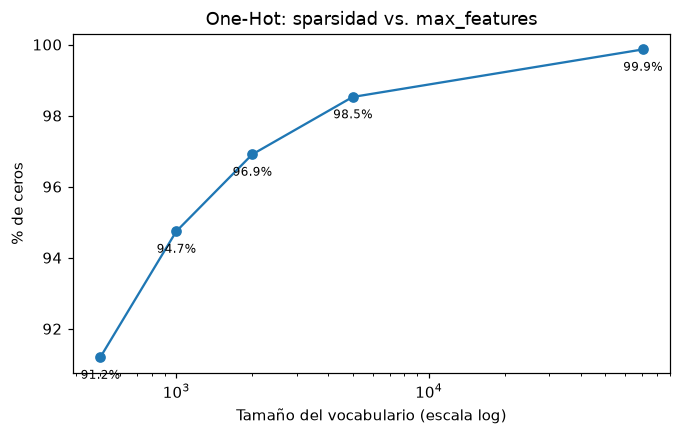

In [7]:
def analizar_one_hot(df):
    """
    TODO:
    1. Aplicar CountVectorizer(binary=True) sobre 'sinapsis_clean'
    2. Imprimir dimensiones de la matriz y porcentaje de ceros (sparsidad)
    3. Graficar cómo cambia la sparsidad al variar max_features
       en [500, 1000, 2000, 5000, None]
    """
    textos = df["sinapsis_clean"]

    # 1-2. Matriz binaria con el vocabulario completo
    X = CountVectorizer(binary=True).fit_transform(textos)
    print(f"Matriz: {X.shape[0]:,} documentos × {X.shape[1]:,} términos")
    print(f"Términos distintos por documento (promedio): {X.nnz / X.shape[0]:.0f}")
    print(f"Sparsidad: {1 - X.nnz / (X.shape[0] * X.shape[1]):.2%}")

    # 3. Sparsidad según el tamaño del vocabulario
    filas = []
    for mf in [500, 1000, 2000, 5000, None]:
        Xm = CountVectorizer(binary=True, max_features=mf).fit_transform(textos)
        filas.append({"max_features": "None (todas)" if mf is None else mf,
                      "n_features": Xm.shape[1],
                      "sparsidad": 1 - Xm.nnz / (Xm.shape[0] * Xm.shape[1])})
    res = pd.DataFrame(filas)
    print()
    print(res.to_string(index=False, formatters={"sparsidad": "{:.2%}".format}))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(res["n_features"], res["sparsidad"] * 100, marker="o")
    ax.set_xscale("log")
    for _, r in res.iterrows():
        ax.annotate(f"{r['sparsidad']:.1%}", (r["n_features"], r["sparsidad"] * 100),
                    textcoords="offset points", xytext=(0, -14), ha="center", fontsize=8)
    ax.set(xlabel="Tamaño del vocabulario (escala log)", ylabel="% de ceros",
           title="One-Hot: sparsidad vs. max_features")
    plt.show()


analizar_one_hot(df)

#### 📝 Interpretación — Ejercicio 3

- Con el vocabulario completo, la matriz es de **8.112 × 70.435** y tiene **99,86 % de ceros**: cada sinopsis usa en promedio **97 términos distintos** de 70 mil posibles.
- Al bajar `max_features`, la sparsidad baja (91 % con 500 términos), porque solo quedan las palabras más frecuentes, que aparecen en muchos documentos. Aun así, más del 90 % de la matriz son ceros.
- **Por qué importa:**
  - **Memoria:** la matriz densa tendría 571 millones de valores; el formato sparse guarda solo los ~790 mil que no son cero.
  - **Similitud:** con vectores tan ralos, dos sinopsis comparten pocas palabras y su similitud casi siempre es baja, aunque hablen de lo mismo con otras palabras. Es una de las limitaciones de las representaciones frecuentistas que motivan los embeddings densos.


---
# Parte 3 – Count Vectorizer

## ¿Qué hace?

A diferencia de One-Hot, Count Vectorizer guarda **cuántas veces** aparece cada
palabra (no solo si aparece o no).

```python
doc = ["el gato come come pescado pescado pescado"]

# One-Hot:  [1, 1, 1, 1]  → "pescado" y "come" valen igual que "el"
# Count:    [1, 2, 1, 3]  → "pescado" ×3 y "come" ×2 se capturan
```

## Parámetros útiles

| Parámetro | Para qué sirve | Ejemplo |
|-----------|---------------|---------|
| `max_features` | Limita el vocabulario a las N palabras más frecuentes | `max_features=5000` |
| `min_df` | Ignora palabras que aparecen en muy pocos documentos | `min_df=2` descarta hapax |
| `max_df` | Ignora palabras que aparecen en casi todos los documentos | `max_df=0.9` descarta stopwords |
| `binary` | Si `True`, equivale a One-Hot | `binary=True` |

**Regla práctica**: casi siempre conviene usar `min_df=2` para descartar palabras
únicas que no ayudan a generalizar.


In [8]:
# ── Ejemplo interactivo: Count Vectorizer ────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

corpus_demo = [
    "el gato come come pescado pescado pescado",
    "el perro come carne",
    "el gato y el perro juegan",
]

# Comparar binary=False vs binary=True
cv_count  = CountVectorizer(binary=False)
cv_binary = CountVectorizer(binary=True)

X_count  = cv_count.fit_transform(corpus_demo)
X_binary = cv_binary.fit_transform(corpus_demo)

idx = [f"d{i+1}" for i in range(len(corpus_demo))]

print("=== CountVectorizer (binary=False) — conteo de frecuencias ===")
df_c = pd.DataFrame(X_count.toarray(),
                    columns=cv_count.get_feature_names_out(), index=idx)
print(df_c.to_string())

print("\n=== CountVectorizer (binary=True) — solo presencia ===")
df_b = pd.DataFrame(X_binary.toarray(),
                    columns=cv_binary.get_feature_names_out(), index=idx)
print(df_b.to_string())

print("\n→ En d1: 'come'×2 y 'pescado'×3 se capturan con binary=False pero no con binary=True")

# Efecto de min_df y max_df
print("\n=== Efecto de min_df=2 (filtra palabras que aparecen en un solo doc) ===")
cv_mindf = CountVectorizer(min_df=2)
X_mindf  = cv_mindf.fit_transform(corpus_demo)
print("Vocabulario:", list(cv_mindf.get_feature_names_out()))


=== CountVectorizer (binary=False) — conteo de frecuencias ===
    carne  come  el  gato  juegan  perro  pescado
d1      0     2   1     1       0      0        3
d2      1     1   1     0       0      1        0
d3      0     0   2     1       1      1        0

=== CountVectorizer (binary=True) — solo presencia ===
    carne  come  el  gato  juegan  perro  pescado
d1      0     1   1     1       0      0        1
d2      1     1   1     0       0      1        0
d3      0     0   1     1       1      1        0

→ En d1: 'come'×2 y 'pescado'×3 se capturan con binary=False pero no con binary=True

=== Efecto de min_df=2 (filtra palabras que aparecen en un solo doc) ===
Vocabulario: ['come', 'el', 'gato', 'perro']


### Ejercicio 4 – Count Vectorizer: `min_df` y `max_df`

 min_df  n_features
      1       70435
      2       33681
      3       24203
      5       16231
     10        9331

 max_df  n_features
    1.0       70435
    0.9       70430
    0.8       70427
    0.7       70424
    0.5       70419



Palabras en más del 50 % de los documentos (las que saca max_df=0.5):
de      0.99
la      0.97
en      0.94
que     0.93
el      0.93
un      0.84
una     0.82
los     0.81
su      0.74
se      0.73
del     0.72
con     0.69
las     0.68
por     0.65
es      0.56
para    0.53

Palabras que aparecen en un solo documento (las que saca min_df=2): 36,754


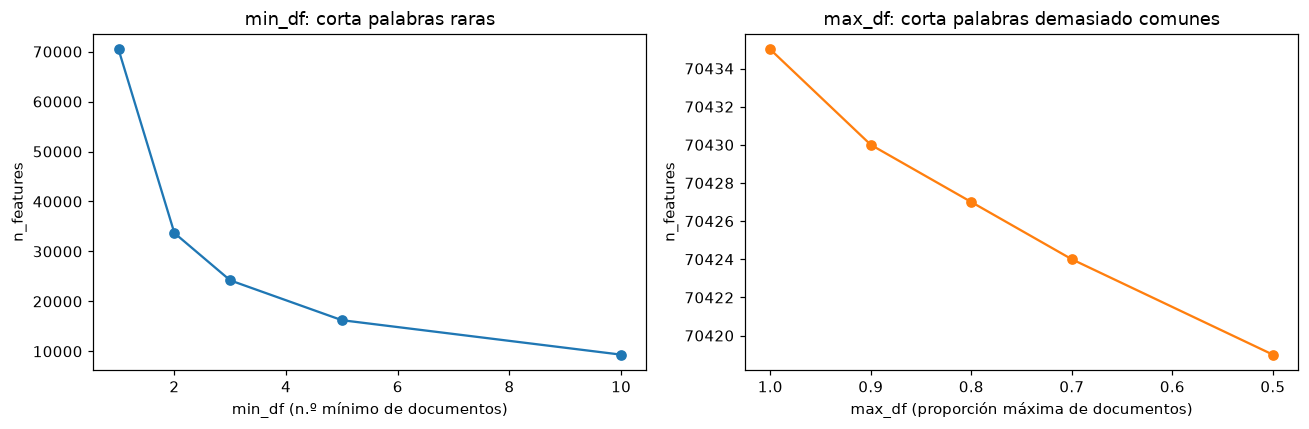

In [9]:
def explorar_count_vectorizer(df):
    """
    TODO:
    1. Probar min_df en [1, 2, 3, 5, 10] — registrar cuántas features quedan
    2. Probar max_df en [1.0, 0.9, 0.8, 0.7, 0.5] — registrar cuántas features quedan
    3. Graficar n_features vs cada parámetro
    """
    textos = df["sinapsis_clean"]
    min_dfs = [1, 2, 3, 5, 10]
    max_dfs = [1.0, 0.9, 0.8, 0.7, 0.5]

    # 1-2. Tamaño del vocabulario para cada valor
    n_min = [len(CountVectorizer(min_df=m).fit(textos).vocabulary_) for m in min_dfs]
    n_max = [len(CountVectorizer(max_df=m).fit(textos).vocabulary_) for m in max_dfs]
    print(pd.DataFrame({"min_df": min_dfs, "n_features": n_min}).to_string(index=False))
    print()
    print(pd.DataFrame({"max_df": max_dfs, "n_features": n_max}).to_string(index=False))

    # ¿Qué palabras recorta max_df? Las que están en más de la mitad de los documentos
    cv = CountVectorizer(binary=True)
    X = cv.fit_transform(textos)
    frac_docs = pd.Series(np.asarray(X.mean(axis=0)).ravel(), index=cv.get_feature_names_out())
    print("\nPalabras en más del 50 % de los documentos (las que saca max_df=0.5):")
    print(frac_docs[frac_docs > 0.5].sort_values(ascending=False).round(2).to_string())
    print(f"\nPalabras que aparecen en un solo documento (las que saca min_df=2): "
          f"{(np.asarray(X.sum(axis=0)).ravel() == 1).sum():,}")

    # 3. Gráficos
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(min_dfs, n_min, marker="o")
    axes[0].set(xlabel="min_df (n.º mínimo de documentos)", ylabel="n_features",
                title="min_df: corta palabras raras")
    axes[1].plot(max_dfs, n_max, marker="o", color="tab:orange")
    axes[1].invert_xaxis()
    axes[1].set(xlabel="max_df (proporción máxima de documentos)", ylabel="n_features",
                title="max_df: corta palabras demasiado comunes")
    plt.tight_layout()
    plt.show()


explorar_count_vectorizer(df)

#### 📝 Interpretación — Ejercicio 4

- **`min_df` es el que más recorta.** Con `min_df=2`, el vocabulario baja de 70.435 a 33.681 términos (−52 %). Es que **36.754 palabras aparecen en un solo documento** (hápax): nombres propios, errores de tipeo, palabras raras. No ayudan a generalizar, porque no se repiten en otros libros. Con `min_df=10` quedan 9.331.
- **`max_df` casi no cambia nada.** Con `max_df=0.5` se van solo **16 palabras**, todas stopwords (*de, la, en, que, el…*; "de" está en el 99 % de las sinopsis). El gráfico de la derecha parece una caída fuerte, pero **ojo con el eje Y**: va de 70.419 a 70.435.
- **Conclusión:** el vocabulario tiene una "cola larga" enorme de palabras raras y muy pocas palabras comunes. `min_df` sirve para reducir la dimensión; `max_df` funciona como un filtro automático de stopwords.


---
# Parte 4 – N-grams

> Esta sección es **solo lectura**: entendé el concepto y ejecutá el ejemplo.
> Los n-grams los vas a usar en el Ejercicio 6 (benchmark).

## ¿Qué son?

Un **n-gram** es una secuencia de n palabras consecutivas.

| Tipo | Ejemplo sobre "primera guerra mundial" |
|------|----------------------------------------|
| Unigram (1) | "primera" · "guerra" · "mundial" |
| Bigram (2) | "primera guerra" · "guerra mundial" |
| Trigram (3) | "primera guerra mundial" |

## ¿Para qué sirven?

Los unigramas pierden el contexto. "no me gustó" tratado palabra a palabra puede
confundirse con "me gustó" porque comparten "me" y "gustó".

El bigrama "no me" o "no gustó" captura esa negación.

En sklearn se controla con `ngram_range=(min_n, max_n)`:

```python
# Solo palabras sueltas
CountVectorizer(ngram_range=(1, 1))

# Palabras sueltas + pares de palabras
CountVectorizer(ngram_range=(1, 2))

# Solo pares
CountVectorizer(ngram_range=(2, 2))
```

> Para clasificación de texto, `ngram_range=(1, 2)` suele mejorar los resultados
> respecto a usar solo unigramas, sin agregar demasiada complejidad.


In [10]:
# ── Ejemplo interactivo: N-grams ─────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer

corpus_demo = [
    "la primera guerra mundial fue terrible",
    "la segunda guerra mundial también fue terrible",
    "el libro sobre la guerra es excelente",
]

configs = {
    "(1,1) — solo unigrams":   (1, 1),
    "(1,2) — uni + bigrams":   (1, 2),
    "(2,2) — solo bigrams":    (2, 2),
    "(1,3) — uni+bi+trigrams": (1, 3),
}

for nombre, rango in configs.items():
    cv  = CountVectorizer(ngram_range=rango, min_df=1)
    X   = cv.fit_transform(corpus_demo)
    print(f"\n=== {nombre} ===")
    print(f"  n_features = {X.shape[1]}")
    print(f"  Vocabulario: {list(cv.get_feature_names_out())}")

print("\n→ Notar cómo 'primera guerra' y 'guerra mundial' son features en (1,2)")
print("→ 'primera guerra mundial' solo aparece como feature en (1,3)")



=== (1,1) — solo unigrams ===
  n_features = 13
  Vocabulario: ['el', 'es', 'excelente', 'fue', 'guerra', 'la', 'libro', 'mundial', 'primera', 'segunda', 'sobre', 'también', 'terrible']

=== (1,2) — uni + bigrams ===
  n_features = 28
  Vocabulario: ['el', 'el libro', 'es', 'es excelente', 'excelente', 'fue', 'fue terrible', 'guerra', 'guerra es', 'guerra mundial', 'la', 'la guerra', 'la primera', 'la segunda', 'libro', 'libro sobre', 'mundial', 'mundial fue', 'mundial también', 'primera', 'primera guerra', 'segunda', 'segunda guerra', 'sobre', 'sobre la', 'también', 'también fue', 'terrible']

=== (2,2) — solo bigrams ===
  n_features = 15
  Vocabulario: ['el libro', 'es excelente', 'fue terrible', 'guerra es', 'guerra mundial', 'la guerra', 'la primera', 'la segunda', 'libro sobre', 'mundial fue', 'mundial también', 'primera guerra', 'segunda guerra', 'sobre la', 'también fue']

=== (1,3) — uni+bi+trigrams ===
  n_features = 42
  Vocabulario: ['el', 'el libro', 'el libro sobre', 'es

---
# Parte 5 – TF-IDF

## El problema con Count Vectorizer

Si usamos solo frecuencias, palabras como "el", "de", "es" tienen conteos altísimos
en todos los documentos. No ayudan a distinguir géneros.

**TF-IDF** combina dos ideas:

- **TF** *(Term Frequency)*: qué tan frecuente es la palabra **en este documento**
- **IDF** *(Inverse Document Frequency)*: penaliza las palabras que aparecen
  en **todos** los documentos (poco útiles para distinguir)

Una palabra frecuente solo en algunos documentos → TF-IDF alto → útil para clasificar.  
Una palabra frecuente en todos los documentos → IDF bajo → peso bajo.

## Ejemplo

```
Corpus de 3 docs. La palabra "el" aparece en todos → IDF bajo → peso bajo.
La palabra "crónica" solo en 1 doc → IDF alto → peso alto.
```

## Parámetros importantes

| Parámetro | Qué hace |
|-----------|---------|
| `sublinear_tf=True` | Usa `log(1 + frecuencia)` en lugar de la frecuencia directa. Evita que documentos largos dominen por repetición. |
| `smooth_idf=True` | Evita errores matemáticos si un término aparece en todos los docs. Conviene dejarlo en `True`. |
| `use_idf=False` | Desactiva el IDF, quedando solo TF normalizado. |

> **Recomendación para empezar**: `TfidfVectorizer(sublinear_tf=True, min_df=2)` es
> un buen punto de partida para clasificación de texto.


In [11]:
# ── Ejemplo interactivo: TF-IDF ──────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

corpus_demo = [
    "el libro es bueno el libro es muy bueno",   # "libro" repetido
    "el libro tiene algunos errores graves",
    "el ensayo es brillante original y único",    # palabras únicas
]

tfidf = TfidfVectorizer()
X     = tfidf.fit_transform(corpus_demo)
feat  = tfidf.get_feature_names_out()

df_tfidf = pd.DataFrame(X.toarray().round(3),
                        columns=feat,
                        index=[f"d{i+1}" for i in range(len(corpus_demo))])
print("=== TF-IDF (smooth_idf=True, sublinear_tf=False) ===")
print(df_tfidf.to_string())

# Mostrar IDF de cada término
idf_series = pd.Series(tfidf.idf_, index=feat).sort_values()
print("\n=== IDF por término (menor = más común en el corpus) ===")
print(idf_series.round(3).to_string())
print("\n→ 'el' y 'es' tienen IDF bajo (aparecen en todos los docs)")
print("→ 'brillante', 'único', 'original' tienen IDF alto (aparecen en 1 solo doc)")

# Comparar sublinear_tf=False vs True
print("\n=== Efecto de sublinear_tf ===")
doc_largo  = ["guerra " * 50 + "economía inflación recesión"]
doc_corto  = ["guerra economía inflación recesión"]

for corpus_ex, label in [(doc_largo, "largo (guerra×50)"), (doc_corto, "corto (guerra×1)")]:
    for sublin, nombre in [(False, "sublinear=False"), (True, "sublinear=True")]:
        v = TfidfVectorizer(sublinear_tf=sublin)
        X_ex = v.fit_transform(corpus_ex)
        idx_guerra = list(v.get_feature_names_out()).index("guerra")
        print(f"  {label} | {nombre}: TF-IDF('guerra') = {X_ex[0, idx_guerra]:.4f}")


=== TF-IDF (smooth_idf=True, sublinear_tf=False) ===
    algunos  brillante  bueno     el  ensayo  errores     es  graves  libro    muy  original  tiene  único
d1    0.000      0.000  0.602  0.356   0.000    0.000  0.458   0.000  0.458  0.301     0.000  0.000  0.000
d2    0.451      0.000  0.000  0.266   0.000    0.451  0.000   0.451  0.343  0.000     0.000  0.451  0.000
d3    0.000      0.451  0.000  0.266   0.451    0.000  0.343   0.000  0.000  0.000     0.451  0.000  0.451

=== IDF por término (menor = más común en el corpus) ===
el           1.000
es           1.288
libro        1.288
brillante    1.693
bueno        1.693
ensayo       1.693
errores      1.693
algunos      1.693
graves       1.693
muy          1.693
original     1.693
tiene        1.693
único        1.693

→ 'el' y 'es' tienen IDF bajo (aparecen en todos los docs)
→ 'brillante', 'único', 'original' tienen IDF alto (aparecen en 1 solo doc)

=== Efecto de sublinear_tf ===
  largo (guerra×50) | sublinear=False: TF-IDF(

### Ejercicio 5 – TF-IDF: Palabras por Género

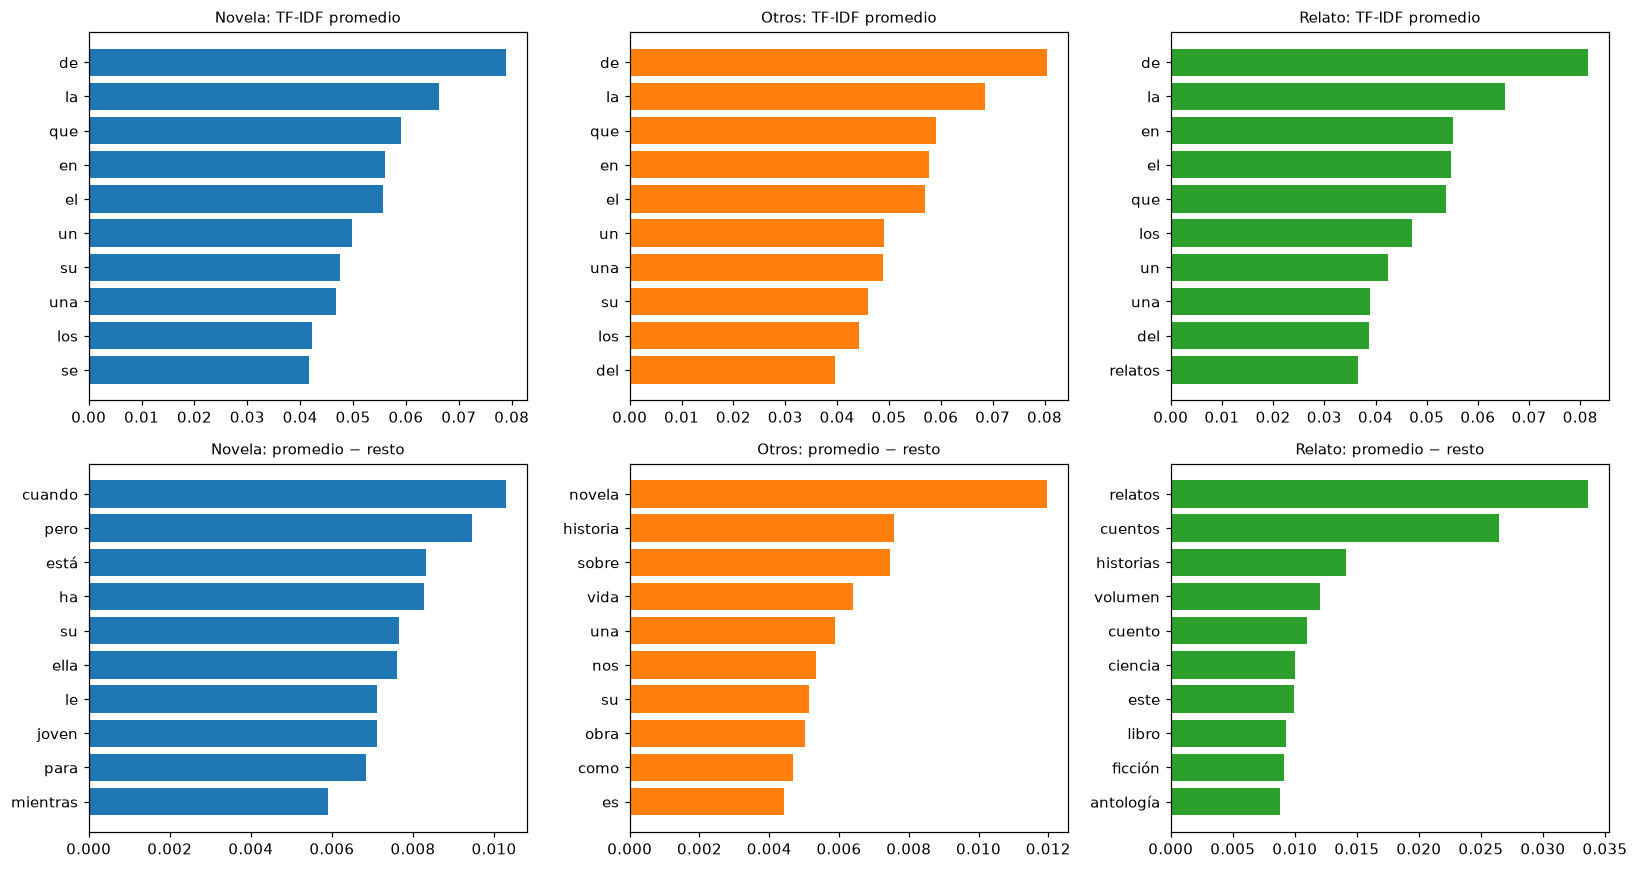

In [12]:
def palabras_por_genero(df):
    """
    TODO:
    1. Vectorizar con TfidfVectorizer(sublinear_tf=True, max_features=5000, min_df=2)
    2. Calcular el TF-IDF promedio por género
    3. Graficar los 10 términos con mayor puntaje para cada género
    """
    # 1. Vectorizar
    tfidf = TfidfVectorizer(sublinear_tf=True, max_features=5000, min_df=2)
    X = tfidf.fit_transform(df["sinapsis_clean"])
    terminos = tfidf.get_feature_names_out()
    generos = sorted(df["label"].unique())

    # 2. TF-IDF promedio de cada término dentro de cada género.
    #    X es sparse: X[filas].mean(axis=0) devuelve una matriz de 1 × n_términos,
    #    y np.asarray(...).ravel() la convierte en un vector común.
    medias = {}
    for g in generos:
        filas_g = (df["label"] == g).to_numpy()
        medias[g] = pd.Series(np.asarray(X[filas_g].mean(axis=0)).ravel(), index=terminos)

    # 3. Top 10 por género.
    #    Fila de arriba: lo pedido (promedio dentro del género).
    #    Fila de abajo: lo que distingue al género (su promedio menos el promedio de los otros).
    fig, axes = plt.subplots(2, len(generos), figsize=(15, 8))
    for j, g in enumerate(generos):
        otros = [medias[o] for o in generos if o != g]
        distintivo = medias[g] - sum(otros) / len(otros)

        top = medias[g].nlargest(10)[::-1]          # [::-1]: el mayor queda arriba en barh
        axes[0, j].barh(top.index, top.values, color=f"C{j}")
        axes[0, j].set_title(f"{g}: TF-IDF promedio", fontsize=10)

        top = distintivo.nlargest(10)[::-1]
        axes[1, j].barh(top.index, top.values, color=f"C{j}")
        axes[1, j].set_title(f"{g}: promedio − resto", fontsize=10)
    plt.tight_layout()
    plt.show()


palabras_por_genero(df)

#### 📝 Interpretación — Ejercicio 5

- **Fila de arriba (lo que pide la consigna):** los 10 términos con mayor TF-IDF promedio son **stopwords**, casi iguales en los tres géneros. El IDF las penaliza porque aparecen en casi todos los documentos, pero su TF es tan alto que igual quedan primeras en el promedio. Este gráfico no dice nada de los géneros: **TF-IDF no reemplaza el filtrado de stopwords** cuando se buscan palabras representativas.
- **Fila de abajo (extra):** al restar el promedio de los otros géneros, aparece lo que distingue a cada clase:
  - **Relato:** *relatos, cuentos, volumen, antología*. Son colecciones de cuentos, y la sinopsis lo dice. Es la clase más fácil.
  - **Otros:** *novela, historia, obra, vida*. Confirma lo del Ejercicio 1: son mayormente novelas sin subgénero, y la sinopsis habla de "la novela" o "la obra".
  - **Novela:** *cuando, pero, mientras, ella, joven*. Son palabras de **narración de trama** ("cuando ella descubre…"), típicas de las sinopsis de novelas de género, como intriga o histórica.
- Que lo distintivo sea **formato y estilo**, y no tema, confirma que las etiquetas miden formato.


---
# Parte 6 – Hash Vectorizer

> Esta sección es **solo lectura**: entendé el concepto y ejecutá el ejemplo.

## ¿Cuándo Count y TF-IDF no alcanzan?

Ambos métodos necesitan construir un **vocabulario** antes de vectorizar.
Con millones de documentos o datos en tiempo real, esto puede ser un problema.

## La solución: el Hashing Trick

En vez de guardar `{"guerra": 42, "economía": 1337, ...}`, aplicamos una función
**hash** directamente a cada palabra para obtener su índice:

```python
indice = hash("guerra") % n_features   # siempre da el mismo número
```

No hay vocabulario que construir ni guardar.

```python
from sklearn.feature_extraction.text import HashingVectorizer

hv = HashingVectorizer(n_features=2**18, norm="l2")

# No necesita fit — transform directo
X = hv.transform(["el gato come pescado", "el perro come carne"])
```

## ¿Cuándo usarlo?

- Corpus muy grande que no cabe en memoria
- Datos en tiempo real (streaming)
- Cuando van a aparecer palabras nuevas en producción

## Parámetro clave: `n_features`

Define el tamaño fijo del vector. Con `2**18` ≈ 260 000 posiciones, las colisiones
(dos palabras distintas con el mismo índice) suelen ser despreciables.


In [13]:
# ── Ejemplo interactivo: Hash Vectorizer ─────────────────────────────────────
from sklearn.feature_extraction.text import HashingVectorizer, CountVectorizer
import numpy as np

corpus_demo = [
    "el gato come pescado",
    "el perro come carne",
    "el gato y el perro juegan",
]

print("=== HashingVectorizer (n_features=2^5=32) ===")
hv = HashingVectorizer(n_features=2**5, norm="l2", alternate_sign=True)
X_hash = hv.transform(corpus_demo)   # ¡No requiere fit!
print(f"Shape:     {X_hash.shape}")
print(f"NNZ total: {X_hash.nnz}")
print(f"NNZ/doc:   {X_hash.nnz / len(corpus_demo):.1f}")

print("\n→ No hay vocabulario almacenado (get_feature_names_out no existe)")
print(f"→ El mismo vectorizador sirve para cualquier texto nuevo sin reentrenar")

# Comparar dimensionalidad con CountVectorizer
cv = CountVectorizer()
X_cv = cv.fit_transform(corpus_demo)
print(f"\nCountVectorizer:  shape = {X_cv.shape}  (vocab = {len(cv.vocabulary_)} términos)")
print(f"HashVectorizer:   shape = {X_hash.shape}  (n_features fijo = 32)")

# Demostrar que no necesita fit: texto completamente nuevo
nuevo_texto = ["zorzal cantó entre los ceibos del litoral"]
X_nuevo = hv.transform(nuevo_texto)  # funciona sin reentrenar
print(f"\nTexto nuevo sin reentrenar: shape = {X_nuevo.shape}")

# Mostrar el problema de alternate_sign con MultinomialNB
print("\n=== alternate_sign y compatibilidad con Naive Bayes ===")
hv_pos = HashingVectorizer(n_features=2**10, norm=None, alternate_sign=False)
hv_alt = HashingVectorizer(n_features=2**10, norm=None, alternate_sign=True)
X_pos  = hv_pos.transform(corpus_demo)
X_alt  = hv_alt.transform(corpus_demo)
print(f"alternate_sign=False → valores negativos: {(X_pos.data < 0).sum()} (cero → OK para MultinomialNB)")
print(f"alternate_sign=True  → valores negativos: {(X_alt.data < 0).sum()} (algunos negativos → NO usar con MultinomialNB)")


=== HashingVectorizer (n_features=2^5=32) ===
Shape:     (3, 32)
NNZ total: 12
NNZ/doc:   4.0

→ No hay vocabulario almacenado (get_feature_names_out no existe)
→ El mismo vectorizador sirve para cualquier texto nuevo sin reentrenar

CountVectorizer:  shape = (3, 7)  (vocab = 7 términos)
HashVectorizer:   shape = (3, 32)  (n_features fijo = 32)

Texto nuevo sin reentrenar: shape = (1, 32)

=== alternate_sign y compatibilidad con Naive Bayes ===
alternate_sign=False → valores negativos: 0 (cero → OK para MultinomialNB)
alternate_sign=True  → valores negativos: 11 (algunos negativos → NO usar con MultinomialNB)


---
# Parte 7 – Comparación de Todos los Métodos

Hasta ahora aprendimos cada vectorizador por separado. Ahora los comparamos
con el mismo clasificador y la misma evaluación para ver cuál funciona mejor.

## Representaciones a comparar

| ID | Método | Configuración |
|----|--------|--------------|
| A | One-Hot | `binary=True, max_features=5000` |
| B | Count | `max_features=5000, min_df=2` |
| C | TF-IDF base | `max_features=5000, min_df=2` |
| D | TF-IDF sublinear | `sublinear_tf=True, max_features=5000` |
| E | TF-IDF bigramas | `ngram_range=(1,2), sublinear_tf=True` |

Clasificador: **Logistic Regression** con 5-fold cross-validation.


### Ejercicio 6 – Comparar Vectorizadores

        método accuracy   std
 TF-IDF sublin    0.694 0.003
   TF-IDF base    0.693 0.006
TF-IDF bigrams    0.691 0.003
       One-Hot    0.639 0.011
         Count    0.638 0.005


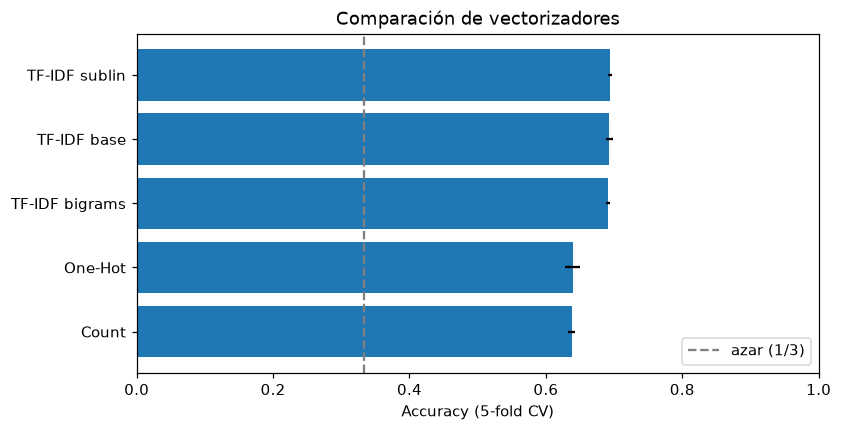

In [14]:
def comparar_vectorizadores(df):
    """
    TODO:
    1. Crear los 5 vectorizadores:
       - One-Hot  (CountVectorizer binary=True, max_features=5000)
       - Count    (CountVectorizer max_features=5000, min_df=2)
       - TF-IDF base    (max_features=5000, min_df=2)
       - TF-IDF sublin  (sublinear_tf=True, max_features=5000, min_df=2)
       - TF-IDF bigrams (ngram_range=(1,2), sublinear_tf=True, max_features=8000)
    2. Evaluar cada uno con LogisticRegression (accuracy, cv=5)
    3. Mostrar tabla y gráfico de barras ordenado de mejor a peor
    """
    y = df["label"]

    # 1. Los 5 vectorizadores
    vectorizadores = {
        "One-Hot":        CountVectorizer(binary=True, max_features=5000),
        "Count":          CountVectorizer(max_features=5000, min_df=2),
        "TF-IDF base":    TfidfVectorizer(max_features=5000, min_df=2),
        "TF-IDF sublin":  TfidfVectorizer(sublinear_tf=True, max_features=5000, min_df=2),
        "TF-IDF bigrams": TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, max_features=8000),
    }

    # 2. Mismo clasificador y misma evaluación para todos: lo único que cambia es la representación
    filas = []
    for nombre, vec in vectorizadores.items():
        X = vec.fit_transform(df["sinapsis_clean"])
        scores = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=5, scoring="accuracy")
        filas.append({"método": nombre, "accuracy": scores.mean(), "std": scores.std()})

    # 3. Tabla y gráfico, de mejor a peor
    res = pd.DataFrame(filas).sort_values("accuracy", ascending=False).reset_index(drop=True)
    print(res.to_string(index=False, formatters={"accuracy": "{:.3f}".format, "std": "{:.3f}".format}))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(res["método"][::-1], res["accuracy"][::-1], xerr=res["std"][::-1], color="tab:blue")
    ax.axvline(1 / y.nunique(), color="gray", ls="--", label="azar (1/3)")
    ax.set(xlabel="Accuracy (5-fold CV)", xlim=(0, 1), title="Comparación de vectorizadores")
    ax.legend(loc="lower right")
    plt.show()


comparar_vectorizadores(df)

#### 📝 Interpretación — Ejercicio 6

- Las tres variantes de **TF-IDF empatan (~0,69)** y superan por unos 5 puntos a **One-Hot y Count (~0,64)**. Todas quedan muy por encima del azar (0,33).
- **Por qué gana TF-IDF:** pondera cada palabra según qué tan específica es (IDF) y normaliza por el largo del documento (norma L2). Count deja que las stopwords dominen con sus conteos altos, y One-Hot trata igual a "de" que a "antología".
- **Sublineal y bigramas no suman acá:** las diferencias (0,003) son menores que el desvío entre folds.
  - **Sublineal:** en sinopsis de ~150 palabras, pocas palabras se repiten mucho, así que el logaritmo casi no cambia nada.
  - **Bigramas:** con `max_features=8000`, probablemente compiten por lugar con unigramas útiles.
- **El techo lo pone la etiqueta, no el vectorizador:** ~0,69 con tres clases que mezclan formato con "sin subgénero". Ver el Extra después del Ejercicio 7.


### Ejercicio 7 – Evaluar el Mejor Modelo

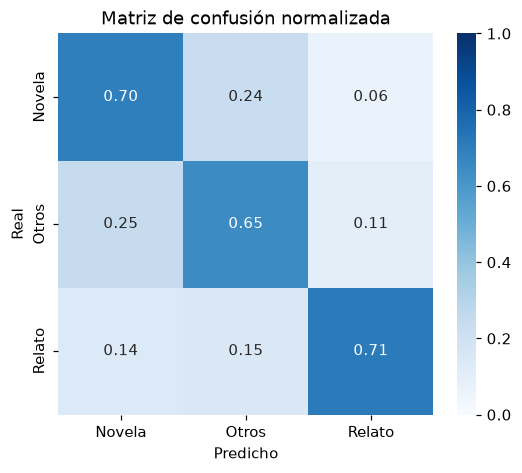

              precision    recall  f1-score   support

      Novela      0.643     0.699     0.670       541
       Otros      0.627     0.647     0.637       541
      Relato      0.807     0.712     0.756       541

    accuracy                          0.686      1623
   macro avg      0.692     0.686     0.688      1623
weighted avg      0.692     0.686     0.688      1623



In [15]:
def evaluar_mejor_modelo(df):
    """
    TODO:
    1. Usar TF-IDF bigramas + LogisticRegression, split 80/20 (stratify=y)
    2. Mostrar la matriz de confusión normalizada
    3. Mostrar el classification report
    """
    # 1. Split 80/20 estratificado (las 3 clases en la misma proporción en train y test)
    txt_train, txt_test, y_train, y_test = train_test_split(
        df["sinapsis_clean"], df["label"], test_size=0.2, stratify=df["label"], random_state=42)

    # El vectorizador aprende vocabulario e IDF solo con train (fit_transform)
    # y después aplica eso mismo a test (transform), como cualquier preprocesamiento
    vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, max_features=8000)
    X_train = vec.fit_transform(txt_train)
    X_test = vec.transform(txt_test)

    modelo = LogisticRegression(max_iter=1000)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    # 2. Matriz de confusión normalizada por fila (cada fila suma 1 = recall de la clase)
    clases = modelo.classes_
    cm = confusion_matrix(y_test, y_pred, labels=clases, normalize="true")
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=clases, yticklabels=clases, ax=ax)
    ax.set(xlabel="Predicho", ylabel="Real", title="Matriz de confusión normalizada")
    plt.show()

    # 3. Classification report
    print(classification_report(y_test, y_pred, digits=3))


evaluar_mejor_modelo(df)

#### 📝 Interpretación — Ejercicio 7

- **Accuracy en test: 0,686**, prácticamente igual que en la validación cruzada (0,691). El resultado no depende de un split favorable.
- **Cómo leer la matriz:** está normalizada por fila, así que cada fila suma 1 y la diagonal es el **recall** de cada clase.
- **Relato es la clase más fácil** (precision 0,81, recall 0,71), porque su sinopsis avisa que se trata de cuentos.
- **Novela y Otros se confunden entre sí:** entre el 24 % y el 25 % de cada una se predice como la otra. Es lo esperable: son novelas el 100 % de "Novela" y el 76 % de "Otros". La única diferencia es que unas tienen un subgénero que empieza con una letra anterior a la N y las otras no.


In [16]:
# ── Extra (no pedido): el mismo modelo con etiquetas temáticas ──────────────
# Libros que tienen exactamente UNO de estos tres géneros, para que la etiqueta no sea ambigua
TEMAS = ["Ciencia ficción", "Policíaco", "Romántico"]

def tema_unico(generos):
    """Devuelve el tema si el libro tiene exactamente uno de TEMAS; si no, None."""
    encontrados = [g for g in generos.split(" - ") if g in TEMAS]
    return encontrados[0] if len(encontrados) == 1 else None

alt = pd.read_csv(DATA_PATH).dropna(subset=["sinapsis", "generos"])
alt["label"] = alt["generos"].apply(tema_unico)
alt = alt.dropna(subset=["label"])
print("Libros por tema:", alt["label"].value_counts().to_dict())

# Los dos datasets, balanceados al mismo tamaño por clase para que la comparación sea justa
n = min(alt["label"].value_counts().min(), df["label"].value_counts().min())
alt = alt.groupby("label", group_keys=False).sample(n=n, random_state=42)
alt["sinapsis_clean"] = alt["sinapsis"].apply(limpiar_texto)
consigna = df.groupby("label", group_keys=False).sample(n=n, random_state=42)

def accuracy_cv(datos):
    """Accuracy (5-fold CV) del mejor modelo del Ejercicio 6: TF-IDF bigramas + LogReg."""
    vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, max_features=8000)
    X = vec.fit_transform(datos["sinapsis_clean"])
    return cross_val_score(LogisticRegression(max_iter=1000), X, datos["label"], cv=5).mean()

print(f"\n{n:,} libros por clase")
print(f"Consigna  (Novela / Otros / Relato):                accuracy = {accuracy_cv(consigna):.3f}")
print(f"Temáticas (Ciencia ficción / Policíaco / Romántico): accuracy = {accuracy_cv(alt):.3f}")


Libros por tema: {'Policíaco': 4900, 'Romántico': 4533, 'Ciencia ficción': 2507}



2,507 libros por clase


Consigna  (Novela / Otros / Relato):                accuracy = 0.691


Temáticas (Ciencia ficción / Policíaco / Romántico): accuracy = 0.899


#### 📝 Interpretación — Extra

- Con el **mismo modelo y la misma cantidad de libros por clase**, cambiar solo las etiquetas lleva la accuracy de **0,69 a 0,90**.
- Ciencia ficción, policíaco y romántico son géneros **temáticos**, con vocabularios propios: justo lo que TF-IDF captura.
- **Lección para el examen:** el rendimiento de un clasificador depende tanto de la representación como de que **la etiqueta tenga relación con el contenido del texto**. Antes de comparar vectorizadores, conviene mirar qué mide la etiqueta.


---
# Parte 8 – Visualización con PCA

Después del benchmark, es útil ver visualmente si los géneros se separan en el
espacio de representación. Usamos **TruncatedSVD** para reducir miles de dimensiones
a solo 2, y hacemos un scatter plot.

```python
from sklearn.decomposition import TruncatedSVD

svd  = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_sparse)   # pasa de (n_docs, n_features) a (n_docs, 2)
```

Si los puntos de cada género forman grupos separados, la representación es más útil.

> Los primeros 2 componentes suelen capturar solo el 10–15% de la varianza total.
> Que los puntos se superpongan no significa que el método sea malo — la separación
> puede existir en otras dimensiones que no podemos ver en 2D.


> ⚠️ **Nota sobre la consigna: esto es LSA, no PCA.**
>
> `TruncatedSVD` sobre una matriz TF-IDF es **LSA** (*Latent Semantic Analysis*). PCA primero **centra** los datos (resta la media de cada columna) y recién después descompone. TruncatedSVD descompone la matriz tal cual.
>
> Se usa TruncatedSVD porque centrar una matriz sparse la vuelve densa: casi todos sus valores dejan de ser cero, y se pierde la ventaja de no guardarlos.
>
> Consecuencia práctica: como el TF-IDF nunca es negativo, la 1.ª componente de LSA suele apuntar hacia el "documento promedio", no en la dirección de mayor varianza.


### Ejercicio 8 – Visualización 2D con PCA

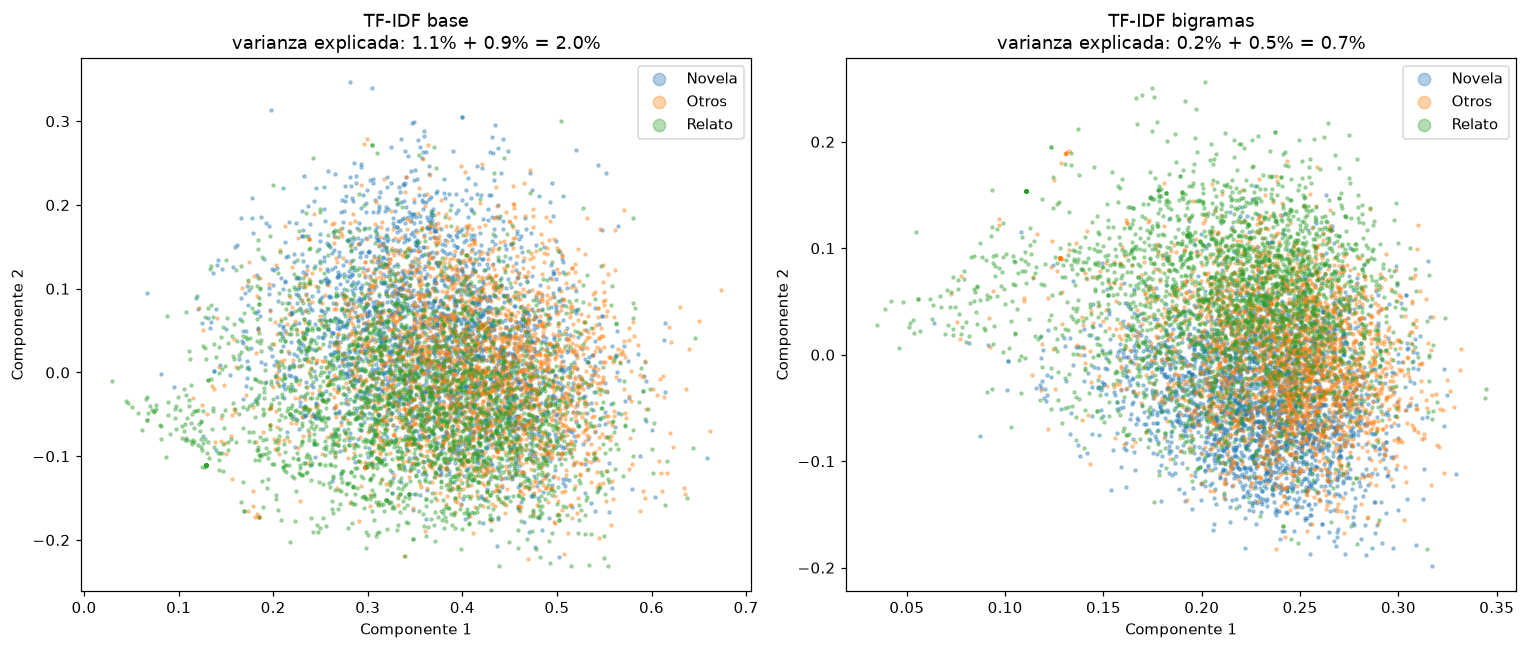

In [17]:
def visualizar_en_2d(df):
    """
    TODO:
    1. Vectorizar con TF-IDF base y TF-IDF bigramas
    2. Reducir a 2 dimensiones con TruncatedSVD(n_components=2)
    3. Hacer un scatter plot coloreado por género para cada representación
    """
    # 1. Las dos representaciones
    representaciones = {
        "TF-IDF base": TfidfVectorizer(max_features=5000, min_df=2),
        "TF-IDF bigramas": TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True,
                                           max_features=8000),
    }
    generos = sorted(df["label"].unique())

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, (nombre, vec) in zip(axes, representaciones.items()):
        X = vec.fit_transform(df["sinapsis_clean"])

        # 2. Reducción a 2D (TruncatedSVD trabaja directo sobre la matriz sparse)
        svd = TruncatedSVD(n_components=2, random_state=42)
        X_2d = svd.fit_transform(X)

        # 3. Scatter coloreado por género
        for g in generos:
            m = (df["label"] == g).to_numpy()
            ax.scatter(X_2d[m, 0], X_2d[m, 1], s=4, alpha=0.35, label=g)
        var = svd.explained_variance_ratio_
        ax.set(title=f"{nombre}\nvarianza explicada: {var[0]:.1%} + {var[1]:.1%} = {var.sum():.1%}",
               xlabel="Componente 1", ylabel="Componente 2")
        ax.legend(markerscale=4)
    plt.tight_layout()
    plt.show()


visualizar_en_2d(df)

In [18]:
# ── Extra: ¿cuánta varianza hace falta para llegar al 10-15 %? ────────────────
X_base = TfidfVectorizer(max_features=5000, min_df=2).fit_transform(df["sinapsis_clean"])
svd_100 = TruncatedSVD(n_components=100, random_state=42).fit(X_base)
acum = svd_100.explained_variance_ratio_.cumsum()
for k in [2, 10, 25, 50, 100]:
    print(f"{k:>3} componentes → {acum[k - 1]:.1%} de la varianza")


  2 componentes → 2.0% de la varianza
 10 componentes → 5.2% de la varianza
 25 componentes → 8.7% de la varianza
 50 componentes → 12.6% de la varianza
100 componentes → 18.1% de la varianza


#### 📝 Interpretación — Ejercicio 8

- **Los tres géneros se superponen casi por completo.** En TF-IDF base, Relato se corre un poco hacia la izquierda; en bigramas, hacia arriba. Novela y Otros quedan mezclados, igual que en la matriz de confusión.
- **Las 2 componentes explican apenas el 2,0 % (base) y el 0,7 % (bigramas)** de la varianza, no el 10–15 % que dice la consigna. Para llegar al 12,6 % hacen falta **50 componentes** (ver la celda Extra). La información del texto está repartida en miles de dimensiones, y ninguna dirección concentra mucha.
- **Por qué no contradice el 0,69 del Ejercicio 6:** el clasificador usa las 5.000 u 8.000 dimensiones, y acá vemos solo 2. Como avisa la consigna, la separación puede existir en dimensiones que no se ven en 2D.
- **La componente 1 siempre es positiva** (el eje X va de 0 a 0,7). Es el efecto de no centrar, descripto en la nota de la Parte 8: esa componente mide cuánto se parece la sinopsis al documento promedio, más que una diferencia entre géneros.
